# Mood Detection with Music Recommendation System
### Practicum Project

This notebook does all the data preparation work and EDA required for the two Spotify datasets used here.

The notebook helps understand the structure of the datasets, look into the audion features and their distribution, and inspect the relationships between all the audio features.


# Importing Libraries

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.preprocessing import StandardScaler
import seaborn as sns

# Loading the Dataset

There are 2 datasets that have been used for this practicum project. 

The datasets have multiple audio features and about 143,000 songs altogether. The audio features will be used to make mood labels and recommendation later on.

In [51]:
from pathlib import Path

cwd = Path.cwd()

if cwd.name == "notebooks":
    PROJECT_ROOT = cwd.parent
else:
    PROJECT_ROOT = cwd

print("Using PROJECT_ROOT:", PROJECT_ROOT)

RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIG_DIR = PROJECT_ROOT / "reports" / "figures"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)
plt.rcParams["figure.figsize"] = (9, 5)

os.makedirs(PROCESSED_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

Using PROJECT_ROOT: /Users/srs/Desktop/REGIS/MSDS692- DATA SCIENCE PRACTICUM/practicum_1_mood_detection_using_music_recommendation_system


In [52]:
import os

print("CWD:", os.getcwd())
print("data exists?", os.path.exists("data"))
print("data/raw exists?", os.path.exists("data/raw"))

if os.path.exists("data"):
    print("Files in data/:", os.listdir("data"))

if os.path.exists("data/raw"):
    print("Files in data/raw/:", os.listdir("data/raw"))

CWD: /Users/srs/Desktop/REGIS/MSDS692- DATA SCIENCE PRACTICUM/practicum_1_mood_detection_using_music_recommendation_system/notebooks
data exists? False
data/raw exists? False


# Inspecting Dataset Structure

The datasets need to be inspected before performing data cleaning. 

This helps know
- The number of rows and columns
- Variable Datatypes
- Possible difference in the dataset. 

In [53]:
df0 = pd.read_csv(RAW_DIR / "spotify_dataset_0.csv")
df1 = pd.read_csv(RAW_DIR / "spotify_dataset_1.csv")

df0.shape, df1.shape

((114000, 21), (32833, 23))

In [54]:
df0.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   index             114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

In [55]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32833 entries, 0 to 32832
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   track_id                  32833 non-null  object 
 1   track_name                32828 non-null  object 
 2   track_artist              32828 non-null  object 
 3   track_popularity          32833 non-null  int64  
 4   track_album_id            32833 non-null  object 
 5   track_album_name          32828 non-null  object 
 6   track_album_release_date  32833 non-null  object 
 7   playlist_name             32833 non-null  object 
 8   playlist_id               32833 non-null  object 
 9   playlist_genre            32833 non-null  object 
 10  playlist_subgenre         32833 non-null  object 
 11  danceability              32833 non-null  float64
 12  energy                    32833 non-null  float64
 13  key                       32833 non-null  int64  
 14  loudne

# Column Standardization

Here, the columns have been lowercase and standardized to ensure consistency. 

In [56]:
df0.columns = df0.columns.str.lower()
df1.columns = df1.columns.str.lower()

In [57]:
rename_map = {
    "danceability": "danceability",
    "energy": "energy",
    "loudness": "loudness",
    "speechiness": "speechiness",
    "acousticness": "acousticness",
    "instrumentalness": "instrumentalness",
    "liveness": "liveness",
    "valence": "valence",
    "tempo": "tempo",
    "artists" :"track_artist"
}
df0 = df0.rename(columns=rename_map)

In [58]:
df0.columns


Index(['index', 'track_id', 'track_artist', 'album_name', 'track_name',
       'popularity', 'duration_ms', 'explicit', 'danceability', 'energy',
       'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature',
       'track_genre'],
      dtype='object')

In [59]:
if "duration_min" in df0.columns:
    df0["duration_ms"] = df0["duration_min"] * 60 * 1000

# Removing Duplicates

To prevent bias in the recommendation, the duplicate tracks have been removed from the dataset using track name, artist name etc. 


In [60]:
print("Before deduction:")
print("df0 shape:", df0.shape)
print("df1 shape:", df1.shape)

df0 = df0.drop_duplicates()
df1 = df1.drop_duplicates()

if "track_id" in df0.columns:
    df0 = df0.drop_duplicates(subset=["track_id"])

if "track_id" in df1.columns:
    df1 = df1.drop_duplicates(subset=["track_id"])

df0 = df0.drop_duplicates(subset=["track_name", "track_artist"])
df1 = df1.drop_duplicates(subset=["track_name", "track_artist"])

print("\nAfter deduction:")
print("df0 shape:", df0.shape)
print("df1 shape:", df1.shape)

Before deduction:
df0 shape: (114000, 21)
df1 shape: (32833, 23)

After deduction:
df0 shape: (81344, 21)
df1 shape: (26230, 23)


In [61]:
df0.duplicated(subset=["track_name", "track_artist"]).sum()
df1.duplicated(subset=["track_name", "track_artist"]).sum()

0

# Combining the datasets

The 2 datasets have been merged into one dataset to improve the diversity of the dataset, which will help with recommendations. 

In [62]:
metadata_cols = ["track_id", "track_name", "track_artist"]

audio_features = [
    "danceability", "energy", "loudness", "speechiness",
    "acousticness", "instrumentalness", "liveness",
    "valence", "tempo", "duration_ms"
]

selected_cols = metadata_cols + audio_features

df0_audio = df0[selected_cols].dropna()
df1_audio = df1[selected_cols].dropna()

In [63]:
df0_audio["source_dataset"] = "spotify_dataset_0"
df1_audio["source_dataset"] = "spotify_dataset_1"

In [64]:
df_combined = pd.concat([df1_audio, df0_audio], ignore_index=True)
print("Combined shape:", df_combined.shape)
df_combined.head()

Combined shape: (107572, 14)


,track_id,track_name,track_artist,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,source_dataset
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,0.748,0.916,-2.634,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754,spotify_dataset_1
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,0.726,0.815,-4.969,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600,spotify_dataset_1
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,0.675,0.931,-3.432,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616,spotify_dataset_1
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,0.718,0.930,-3.778,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093,spotify_dataset_1
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,0.650,0.833,-4.672,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052,spotify_dataset_1


# EDA


## Feature Distribution Plot

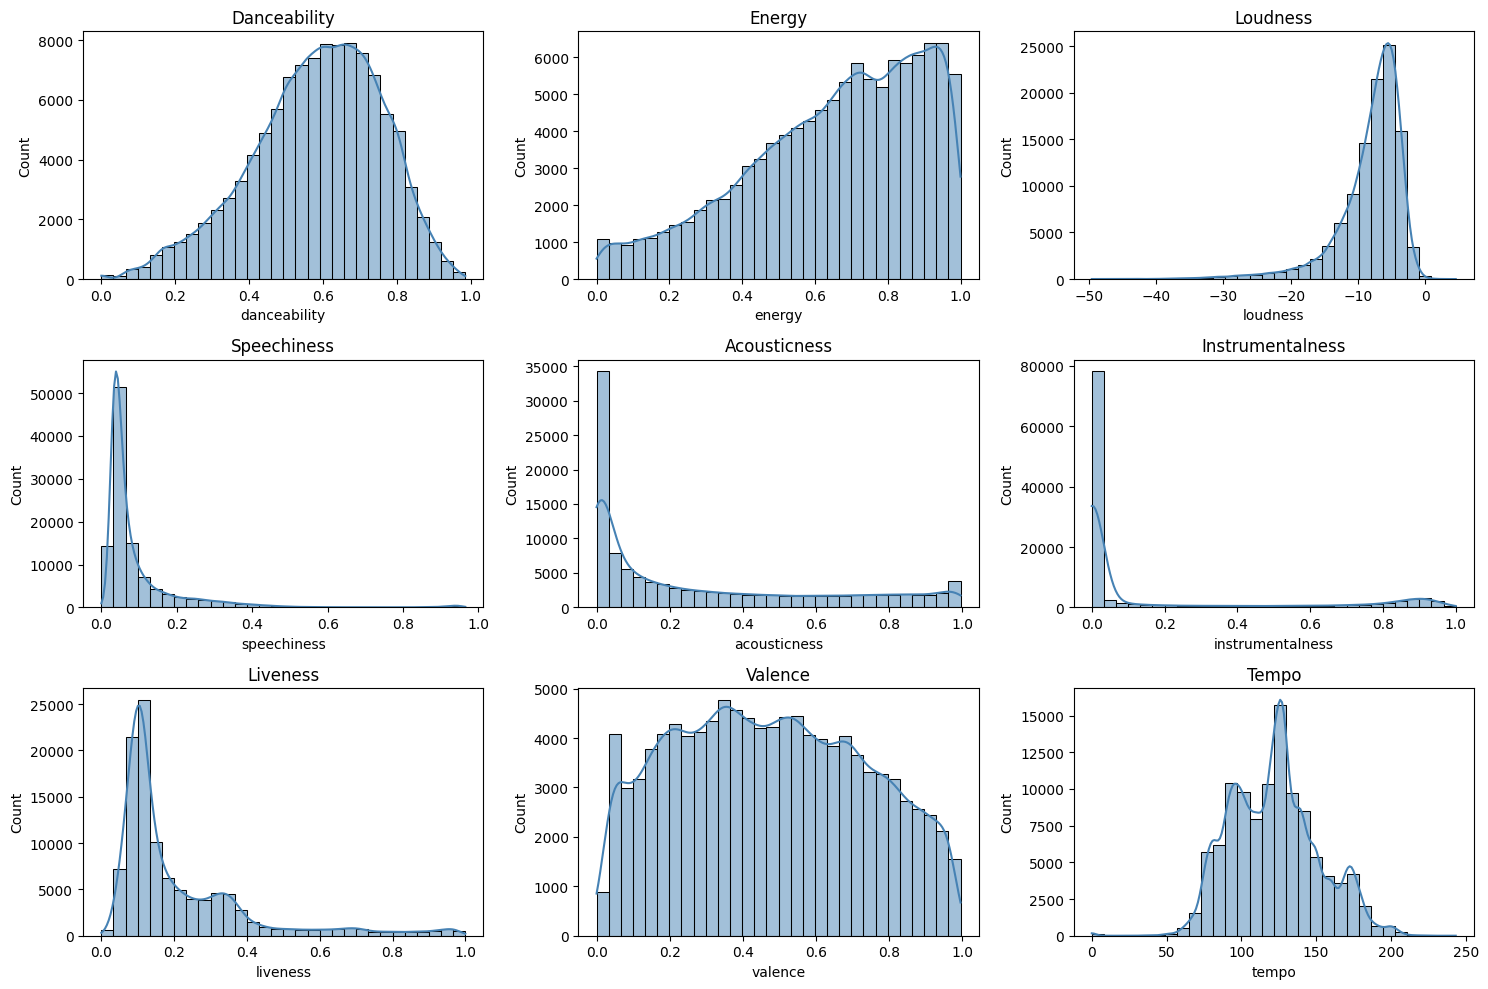

In [65]:
features = [
    'danceability',
    'energy',
    'loudness',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'valence',
    'tempo'
]

plt.figure(figsize=(15,10))

for i, feature in enumerate(features, 1):
    plt.subplot(3,3,i)
    sns.histplot(df_combined[feature], bins=30, kde=True, color='steelblue')
    plt.title(feature.capitalize())

plt.tight_layout()
plt.savefig(FIG_DIR / "feature_distributions.png", dpi=300)
plt.show()

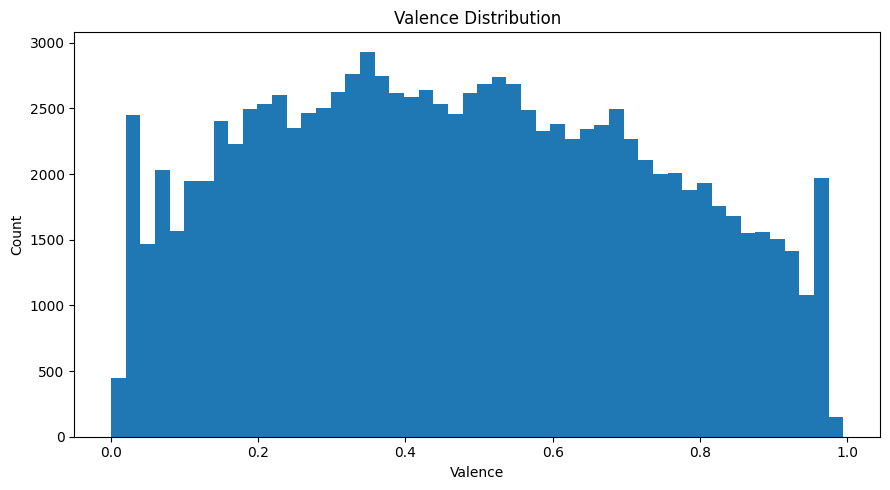

In [66]:
plt.hist(df_combined["valence"], bins=50)
plt.title("Valence Distribution")
plt.xlabel("Valence")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "valence_distribution.png"), dpi=200)
plt.show()

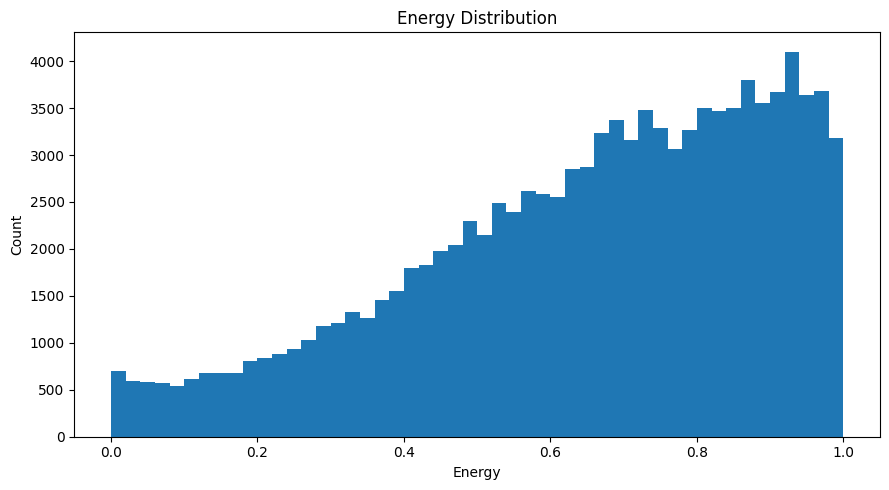

In [67]:
plt.hist(df_combined["energy"], bins=50)
plt.title("Energy Distribution")
plt.xlabel("Energy")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "energy_distribution.png"), dpi=200)
plt.show()

## FEATURE RELATIONSHIP PLOTS

A scatter plot is used to examine the relationship between **valence** and **energy**.

Valence represents the postivity of a song whereas energy works with the intensity of a songs. 

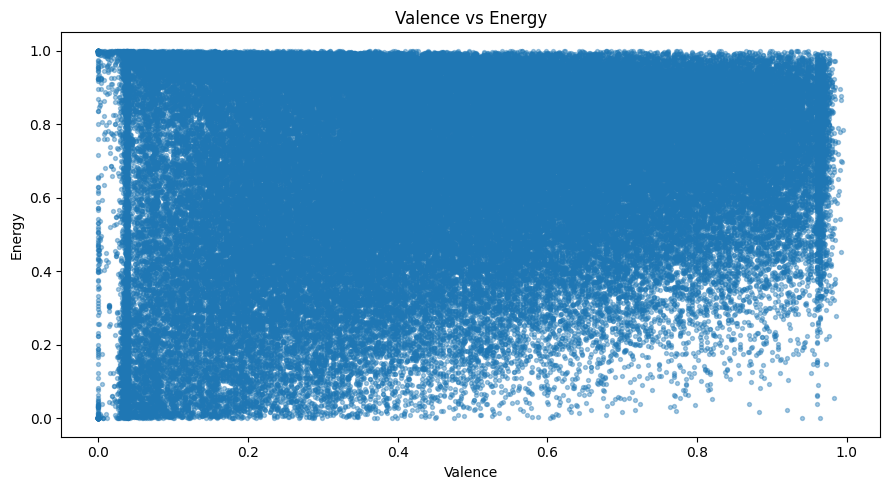

In [68]:
plt.scatter(df_combined["valence"], df_combined["energy"], s=8, alpha=0.4)
plt.xlabel("Valence")
plt.ylabel("Energy")
plt.title("Valence vs Energy")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "valence_vs_energy.png"), dpi=200)
plt.show()

# CORRELATION MATRIX

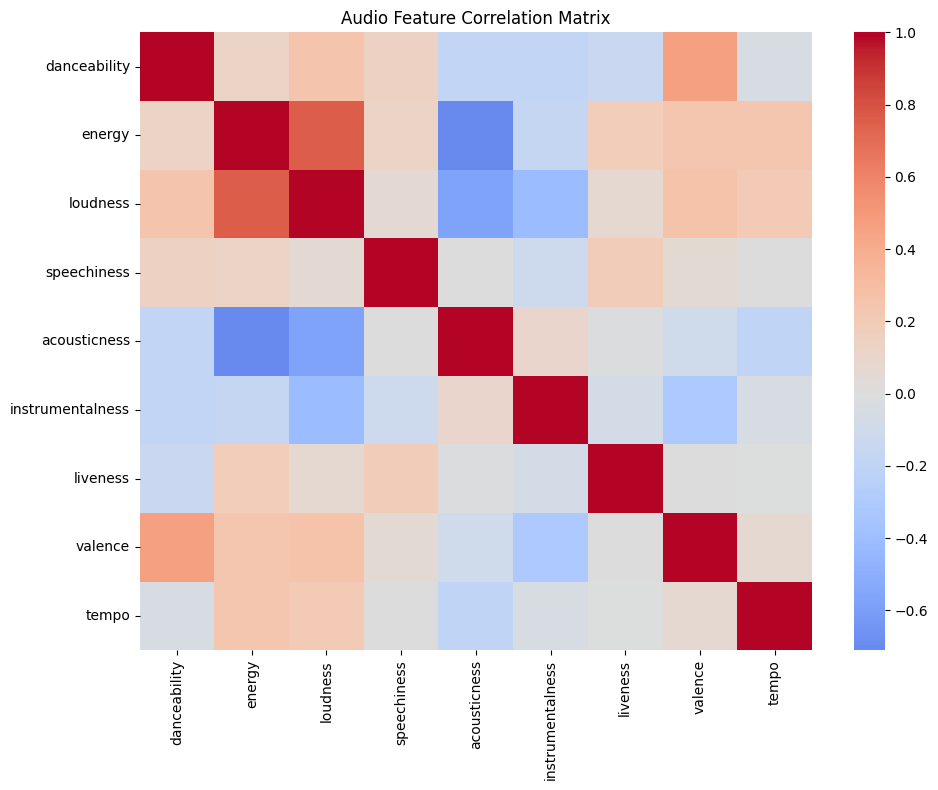

In [69]:
import seaborn as sns
import matplotlib.pyplot as plt

audio_cols = [
    "danceability", "energy", "loudness", "speechiness",
    "acousticness", "instrumentalness", "liveness",
    "valence", "tempo"
]

corr = df_combined[audio_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
plt.title("Audio Feature Correlation Matrix")
plt.tight_layout()
plt.show()

# FEATURE SCALING

Primary audio features such as valence, danceability, tempo, energy, and loudness are measured differently. So, scaling is necessary to avoid distortions in the similarity calculations.

In [70]:
mood_features = ["valence", "energy", "danceability", "tempo", "loudness"]

scaler = StandardScaler()
df_scaled = df_combined.copy()
df_scaled[mood_features] = scaler.fit_transform(df_scaled[mood_features])

In [71]:
df_combined = pd.concat([df1_audio, df0_audio], ignore_index=True)
print("Combined shape:", df_combined.shape)
df_combined.head()

Combined shape: (107572, 14)


,track_id,track_name,track_artist,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,source_dataset
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,0.748,0.916,-2.634,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754,spotify_dataset_1
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,0.726,0.815,-4.969,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600,spotify_dataset_1
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,0.675,0.931,-3.432,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616,spotify_dataset_1
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,0.718,0.930,-3.778,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093,spotify_dataset_1
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,0.650,0.833,-4.672,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052,spotify_dataset_1


In [72]:
df_combined = df_combined.drop_duplicates(
    subset=["track_name", "track_artist"],
    keep="first"
).reset_index(drop=True)

In [73]:
print("Number of songs:", df_combined.shape[0])
print("Number of columns:", df_combined.shape[1])

Number of songs: 105477
Number of columns: 14


# Processed Dataset

After cleaning, merging, and scaling the audio features, the processed dataset is saved for use in later stages of the project.


In [74]:
df_scaled.to_csv(
    os.path.join(PROCESSED_DIR, "spotify_combined_audio_features.csv"),
    index=False
)